In [256]:
%pip install pandas numpy matplotlib seaborn geopandas shapely statsmodels

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

import statsmodels.api as sm

4867.22s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [257]:
ridership = pd.read_csv("resources/ridership_by_station.csv")
ridership.head()

,station_id,stationname,date,daytype,rides
0,40350,UIC-Halsted,01/01/2001,U,273
1,41130,Halsted-Orange,01/01/2001,U,306
2,40760,Granville,01/01/2001,U,"1,059"
3,40070,Jackson/Dearborn,01/01/2001,U,649
4,40090,Damen-Brown,01/01/2001,U,411


In [258]:
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['daytype'] = ridership['daytype'].astype('category')
ridership['rides'] = ridership['rides'].str.replace(',', '').astype(int)
ridership.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298399 entries, 0 to 1298398
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   station_id   1298399 non-null  int64         
 1   stationname  1298399 non-null  object        
 2   date         1298399 non-null  datetime64[ns]
 3   daytype      1298399 non-null  category      
 4   rides        1298399 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(2), object(1)
memory usage: 40.9+ MB


In [259]:
ridership.head()

,station_id,stationname,date,daytype,rides
0,40350,UIC-Halsted,2001-01-01,U,273
1,41130,Halsted-Orange,2001-01-01,U,306
2,40760,Granville,2001-01-01,U,1059
3,40070,Jackson/Dearborn,2001-01-01,U,649
4,40090,Damen-Brown,2001-01-01,U,411


In [262]:
weather = pd.read_csv("resources/weather_data.csv")
weather['date'] = pd.to_datetime(weather['DATE'])
weather.head()

,STATION,NAME,DATE,AWND,PRCP,SNOW,SNWD,TAVG,Fog_Ice_Fog,Heavy_Fog,Thunder,Ice_Pellets_Sleet,Hail,Glaze_Rime,Dust_Ash_Sand,Smoke_Haze,Blowing_Snow,Tornado_Funnel_Cloud,High_Winds,date
0,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-01,7.38,0.00,0.0,0.0,42.0,0,0,0,0,0,0,0,0,0,0,0,2000-01-01
1,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-02,13.87,0.01,0.0,0.0,48.0,1,0,0,0,0,0,0,0,0,0,0,2000-01-02
2,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-03,12.75,0.25,0.4,0.0,35.0,1,0,0,0,0,0,0,0,0,0,0,2000-01-03
3,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-04,13.42,0.00,0.0,0.0,28.0,1,0,0,0,0,0,0,0,0,0,0,2000-01-04
4,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-05,11.18,0.00,0.0,0.0,20.0,1,0,0,0,0,0,0,0,0,0,0,2000-01-05


In [263]:
ridership_weather = ridership.merge(weather, left_on='date', right_on='date', how='left')
ridership_weather.drop(columns=['DATE', 'STATION'], inplace=True)

ridership_weather.head()

,station_id,stationname,date,daytype,rides,NAME,AWND,PRCP,SNOW,SNWD,...,Heavy_Fog,Thunder,Ice_Pellets_Sleet,Hail,Glaze_Rime,Dust_Ash_Sand,Smoke_Haze,Blowing_Snow,Tornado_Funnel_Cloud,High_Winds
0,40350,UIC-Halsted,2001-01-01,U,273,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.0,0.0,17.0,...,0,0,0,0,0,0,0,0,0,0
1,41130,Halsted-Orange,2001-01-01,U,306,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.0,0.0,17.0,...,0,0,0,0,0,0,0,0,0,0
2,40760,Granville,2001-01-01,U,1059,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.0,0.0,17.0,...,0,0,0,0,0,0,0,0,0,0
3,40070,Jackson/Dearborn,2001-01-01,U,649,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.0,0.0,17.0,...,0,0,0,0,0,0,0,0,0,0
4,40090,Damen-Brown,2001-01-01,U,411,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.0,0.0,17.0,...,0,0,0,0,0,0,0,0,0,0


In [264]:
ridership_weather.columns

Index(['station_id', 'stationname', 'date', 'daytype', 'rides', 'NAME', 'AWND',
       'PRCP', 'SNOW', 'SNWD', 'TAVG', 'Fog_Ice_Fog', 'Heavy_Fog', 'Thunder',
       'Ice_Pellets_Sleet', 'Hail', 'Glaze_Rime', 'Dust_Ash_Sand',
       'Smoke_Haze', 'Blowing_Snow', 'Tornado_Funnel_Cloud', 'High_Winds'],
      dtype='object')

In [265]:
station_info = pd.read_csv("resources/system_info.csv")
station_info.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,False,False,False,False,False,"(41.831677, -87.625826)"


In [266]:
station_info['DIRECTION_ID'] = station_info['DIRECTION_ID'].astype('category')
station_info['MAP_ID'] = station_info['MAP_ID'].astype(int)
for col in station_info.select_dtypes(include=['bool']).columns:
    station_info[col] = station_info[col].astype(int)

station_info[['latitude', 'longitude']] = station_info['Location'].str.strip().str.strip('()').str.split(', ', expand=True)
station_info['latitude'] = pd.to_numeric(station_info['latitude'].str.strip())
station_info['longitude'] = pd.to_numeric(station_info['longitude'].str.strip())
station_info = station_info[['STATION_NAME', 'DIRECTION_ID', 'MAP_ID', 'ADA', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude']]
station_info.head()

,STATION_NAME,DIRECTION_ID,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,latitude,longitude
0,18th,W,40830,1,0,0,0,0,0,0,1,0,41.857908,-87.669147
1,18th,E,40830,1,0,0,0,0,0,0,1,0,41.857908,-87.669147
2,35th/Archer,N,40120,1,0,0,0,0,0,0,0,1,41.829353,-87.680622
3,35th/Archer,S,40120,1,0,0,0,0,0,0,0,1,41.829353,-87.680622
4,35th-Bronzeville-IIT,N,41120,1,0,0,1,0,0,0,0,0,41.831677,-87.625826


In [267]:
#Identify which stations have conflicting ADA status (i.e. part of station or certain lines are ADA compliant while others aren't)
grouped_ada = station_info.groupby('MAP_ID')['ADA'].apply(lambda x: x.unique())
conflicting_stations = grouped_ada[grouped_ada.apply(lambda x: 0 in x and 1 in x)].index.tolist()

print("STATION_NAMEs with conflicting ADA values:", conflicting_stations)

STATION_NAMEs with conflicting ADA values: []


In [268]:
agg_dict = {
    'STATION_NAME': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'DIRECTION_ID': lambda x: tuple(x.unique()),
    'ADA': 'max',
    'RED': 'max',
    'BLUE': 'max',
    'G': 'max',
    'BRN': 'max',
    'P': 'max',
    'Y': 'max',
    'Pnk': 'max',
    'O': 'max'
}

si_aggregated = station_info.groupby('MAP_ID').agg(agg_dict).reset_index()
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,DIRECTION_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O
0,40010,Austin,41.870851,-87.776812,"(W, E)",0,0,1,0,0,0,0,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,"(W, E)",1,0,0,1,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,"(W, E)",1,0,0,1,0,0,0,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,"(N, S)",1,0,0,0,1,1,0,1,1
4,40050,Davis,42.047710,-87.683543,"(N, S)",1,0,0,0,0,1,0,0,0


In [269]:
#Turn direction into a dummy variable
direction_dummies = si_aggregated['DIRECTION_ID'].apply(lambda x: '|'.join(map(str, x))).str.get_dummies()
si_aggregated = si_aggregated.join(direction_dummies).drop(columns=['DIRECTION_ID'])
si_aggregated['N/S'] = si_aggregated['N'] | si_aggregated['S']
si_aggregated['E/W'] = si_aggregated['E'] | si_aggregated['W']
si_aggregated = si_aggregated.drop(columns=['N', 'S', 'E', 'W'])
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0


In [270]:
station_ridership = pd.merge(ridership_weather, si_aggregated, left_on='station_id', right_on='MAP_ID', how='left')
display(station_ridership)

,station_id,stationname,date,daytype,rides,NAME,AWND,PRCP,SNOW,SNWD,...,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40350,UIC-Halsted,2001-01-01,U,273,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.00,0.0,17.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,41130,Halsted-Orange,2001-01-01,U,306,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.00,0.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,40760,Granville,2001-01-01,U,1059,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.00,0.0,17.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,40070,Jackson/Dearborn,2001-01-01,U,649,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.00,0.0,17.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,40090,Damen-Brown,2001-01-01,U,411,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.00,0.0,17.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41670,Conservatory,2025-11-30,U,307,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",11.18,0.02,0.3,7.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298395,41680,Oakton-Skokie,2025-11-30,U,162,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",11.18,0.02,0.3,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1298396,41690,Cermak-McCormick Place,2025-11-30,U,715,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",11.18,0.02,0.3,7.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1298397,41700,Washington/Wabash,2025-11-30,U,2704,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",11.18,0.02,0.3,7.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0


In [271]:
start_date = pd.to_datetime('2000-01-01')
station_ridership['days_since_2000'] = (station_ridership['date'] - start_date).dt.days

#Calculate month (as integer)
station_ridership['month'] = station_ridership['date'].dt.month

#Calculate year
station_ridership['year'] = station_ridership['date'].dt.year

#Calculate season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
station_ridership['season'] = station_ridership['month'].apply(get_season)

#Display the first few rows with the new columns
print(station_ridership[['date', 'days_since_2000', 'season', 'month', 'year']].head())

        date  days_since_2000  season  month  year
0 2001-01-01              366  Winter      1  2001
1 2001-01-01              366  Winter      1  2001
2 2001-01-01              366  Winter      1  2001
3 2001-01-01              366  Winter      1  2001
4 2001-01-01              366  Winter      1  2001


In [272]:
#Identify rows with missing latitude or longitude
missing_coords_df = station_ridership[station_ridership['latitude'].isnull() | station_ridership['longitude'].isnull()]

#Get unique station names with missing coordinates, excluding NaN values
unique_stations_missing_coords = missing_coords_df['stationname'].dropna().unique()

if len(unique_stations_missing_coords) == 0:
    print("No stations found with missing latitude or longitude values.")
else:
    print("Stations with missing latitude or longitude values and their date range:")
    for station_name in unique_stations_missing_coords:
        # Filter for the current station and missing coordinates using 'stationname'
        station_missing_data = missing_coords_df[missing_coords_df['stationname'] == station_name]

        # Get the first and last date for this station's missing coordinates
        first_date = station_missing_data['date'].min()
        last_date = station_missing_data['date'].max()

        print(f"{station_name}, {first_date.strftime('%Y-%m-%d')} through {last_date.strftime('%Y-%m-%d')}")

Stations with missing latitude or longitude values and their date range:
Randolph/Wabash, 2001-01-01 through 2019-01-31
Madison/Wabash, 2001-01-01 through 2018-01-01
Washington/State, 2001-01-01 through 2009-01-31
Homan, 2001-07-01 through 2001-07-31


<Axes: >

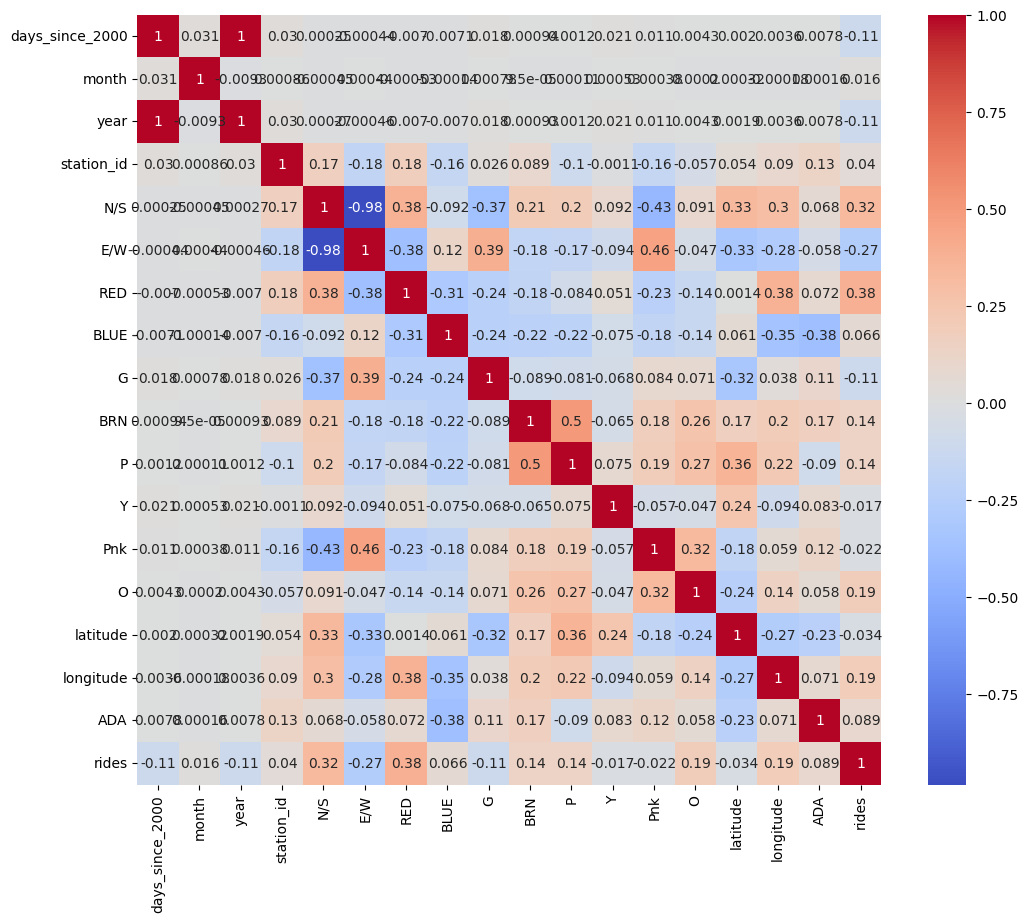

In [273]:
columns_for_splom = ['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA', 'rides']

#See correlations
plt.figure(figsize=(12,10))
sns.heatmap(station_ridership[columns_for_splom].corr(), annot=True, cmap='coolwarm')

In [274]:
# sns.pairplot(station_ridership, x_vars=['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA'], y_vars=['rides'])
# plt.show()

In [275]:
# sns.pairplot(station_ridership[['days_since_2000', 'month', 'year', 'station_id', 'latitude', 'longitude', 'rides']])
# plt.show()

In [276]:
zoning_df = pd.read_csv("resources/zoning_districts_2026.csv")

# Convert WKT strings to actual geometry objects
zoning_df['geometry'] = zoning_df['the_geom'].apply(wkt.loads)
zoning_df['ZONE_TYPE'] = zoning_df['ZONE_CLASS'].apply(lambda x: re.split(r'[-\s]+', x)[0])
# Now create the GeoDataFrame with the geometry column
zoning_gdf = gpd.GeoDataFrame(zoning_df, geometry='geometry', crs='EPSG:4326')

zone_classes = sorted(zoning_gdf['ZONE_TYPE'].unique())
for zone_class in zone_classes:
    print(f"CLASS: {zone_class}")
    print("\n")

print(zoning_gdf['geometry'])

CLASS: B1


CLASS: B2


CLASS: B3


CLASS: C1


CLASS: C2


CLASS: C3


CLASS: DC


CLASS: DR


CLASS: DS


CLASS: DX


CLASS: M1


CLASS: M2


CLASS: M3


CLASS: PD


CLASS: PMD


CLASS: PMD13


CLASS: POS


CLASS: RM


CLASS: RM4


CLASS: RM4.5


CLASS: RM5.5


CLASS: RS


CLASS: RT


CLASS: T


0        MULTIPOLYGON (((-87.69617 41.87643, -87.69616 ...
1        MULTIPOLYGON (((-87.7468 41.95937, -87.74678 4...
2        MULTIPOLYGON (((-87.67166 41.78622, -87.67169 ...
3        MULTIPOLYGON (((-87.55061 41.73191, -87.55073 ...
4        MULTIPOLYGON (((-87.7868 41.96888, -87.7868 41...
                               ...                        
14869    MULTIPOLYGON (((-87.67037 41.89093, -87.67045 ...
14870    MULTIPOLYGON (((-87.67276 41.89089, -87.67285 ...
14871    MULTIPOLYGON (((-87.66206 41.88661, -87.66156 ...
14872    MULTIPOLYGON (((-87.63779 41.85835, -87.63779 ...
14873    MULTIPOLYGON (((-87.67331 41.89127, -87.67338 ...
Name: geometry, Length: 14874, dtype: geometry


/tmp/ipykernel_727967/553784424.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  zone_cmap = plt.cm.get_cmap('tab20', len(zone_types))


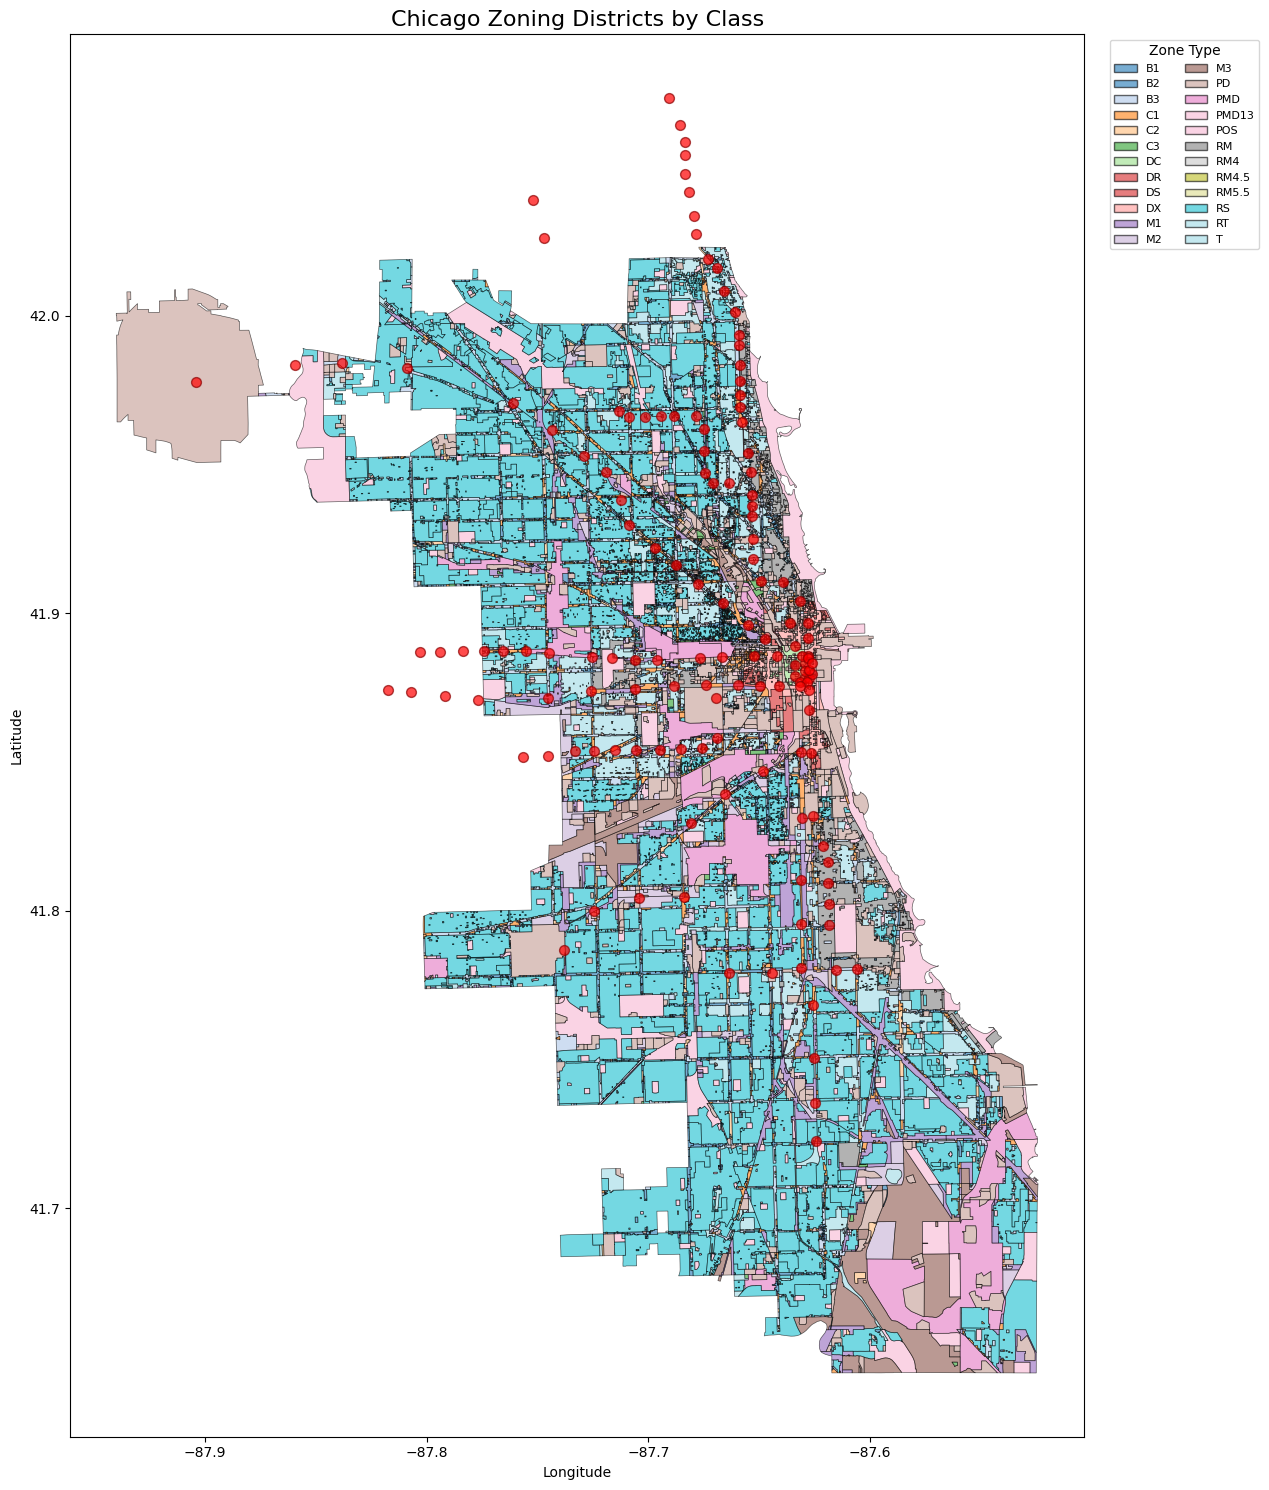

In [277]:
# Plot the zoning districts
from matplotlib.patches import Patch


fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Add station locations
ax.scatter(si_aggregated['longitude'], si_aggregated['latitude'], 
           c='red', s=50, alpha=0.7, edgecolors='darkred', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago Zoning Districts by Class', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Build zone-color legend (matching ZONE_TYPE categories)
zone_types = sorted(zoning_gdf['ZONE_TYPE'].dropna().unique())
zone_cmap = plt.cm.get_cmap('tab20', len(zone_types))
zone_handles = [
    Patch(facecolor=zone_cmap(i), edgecolor='black', alpha=0.6, label=z)
    for i, z in enumerate(zone_types)
]
ax.legend(handles=zone_handles, title='Zone Type', loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=8, title_fontsize=10, ncol=2, frameon=True)
plt.tight_layout()
plt.show()

In [278]:
# Most common zoning categories (by ZONE_TYPE)
most_common_zones = zoning_gdf['ZONE_TYPE'].value_counts().rename_axis('ZONE_TYPE').reset_index(name='count')
display(most_common_zones)

,ZONE_TYPE,count
0,B3,2387
1,RT,2248
2,PD,1450
3,RM,1426
4,RS,1398
5,C1,1392
6,B1,1103
7,B2,1068
8,POS,563
9,C2,554


You can find what each zone type with the below guide

https://secondcityzoning.org/zones/

In [279]:
# Most zone areas in square miles (by ZONE_TYPE)
zoning_gdf['area'] = zoning_gdf['geometry'].area
zone_area = zoning_gdf.groupby('ZONE_TYPE')['area'].sum().reset_index(name='total_area').sort_values(by='total_area', ascending=False)
# Recompute area in square miles (project to meters first)
zoning_gdf['area'] = zoning_gdf.to_crs('EPSG:2790').geometry.area / (1609.344 ** 2)

zone_area = (
    zoning_gdf.groupby('ZONE_TYPE')['area']
    .sum()
    .reset_index(name='total_area_sq_miles')
    .sort_values(by='total_area_sq_miles', ascending=False)
)

display(zone_area)

/tmp/ipykernel_727967/1701511150.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zoning_gdf['area'] = zoning_gdf['geometry'].area


,ZONE_TYPE,total_area_sq_miles
21,RS,93.293384
13,PD,32.458510
22,RT,18.513294
16,POS,17.591912
14,PMD,12.181355
2,B3,10.317112
10,M1,9.208676
12,M3,8.938126
17,RM,7.044858
11,M2,5.832498


In [280]:
# Create a GeoDataFrame with station locations with shapes representing a 1 mile buffer around each station
si_gdf = gpd.GeoDataFrame(
    si_aggregated,
    geometry=gpd.points_from_xy(si_aggregated['longitude'], si_aggregated['latitude']),
    crs='EPSG:4326'
)

# Project to a projected CRS that uses meters (Chicago area: NAD83 / Illinois East)
si_gdf_projected = si_gdf.to_crs('EPSG:2790')

# Create 1-mile buffers (1 mile = 1609.34 meters)
feet_per_mile = 5280
meters_per_foot = 0.3048
meters_per_mile = feet_per_mile * meters_per_foot  # 1609.344 meters

si_gdf_projected['geometry_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile)
si_gdf_projected['geometry_half_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile / 2)

# WGS84 is EPSG:4326, where coordinates are in decimal degrees
# (x = longitude, y = latitude), not linear units like meters/feet.
si_gdf['geometry_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)

si_gdf['geometry_half_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_half_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)
display(si_gdf.head())

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W,geometry,geometry_mile,geometry_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1,POINT (-87.77681 41.87085),"POLYGON ((-87.75743 41.87076, -87.75753 41.869...","POLYGON ((-87.76712 41.8708, -87.76717 41.8700..."
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.80318 41.88685),"POLYGON ((-87.78379 41.88676, -87.78389 41.885...","POLYGON ((-87.79348 41.8868, -87.79353 41.8860..."
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.7254 41.88541),"POLYGON ((-87.70601 41.88531, -87.70612 41.883...","POLYGON ((-87.71571 41.88536, -87.71576 41.884..."
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0,POINT (-87.63374 41.87872),"POLYGON ((-87.61435 41.8786, -87.61446 41.8771...","POLYGON ((-87.62405 41.87866, -87.6241 41.8779..."
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0,POINT (-87.68354 42.04771),"POLYGON ((-87.6641 42.0476, -87.66421 42.04618...","POLYGON ((-87.67382 42.04765, -87.67388 42.046..."


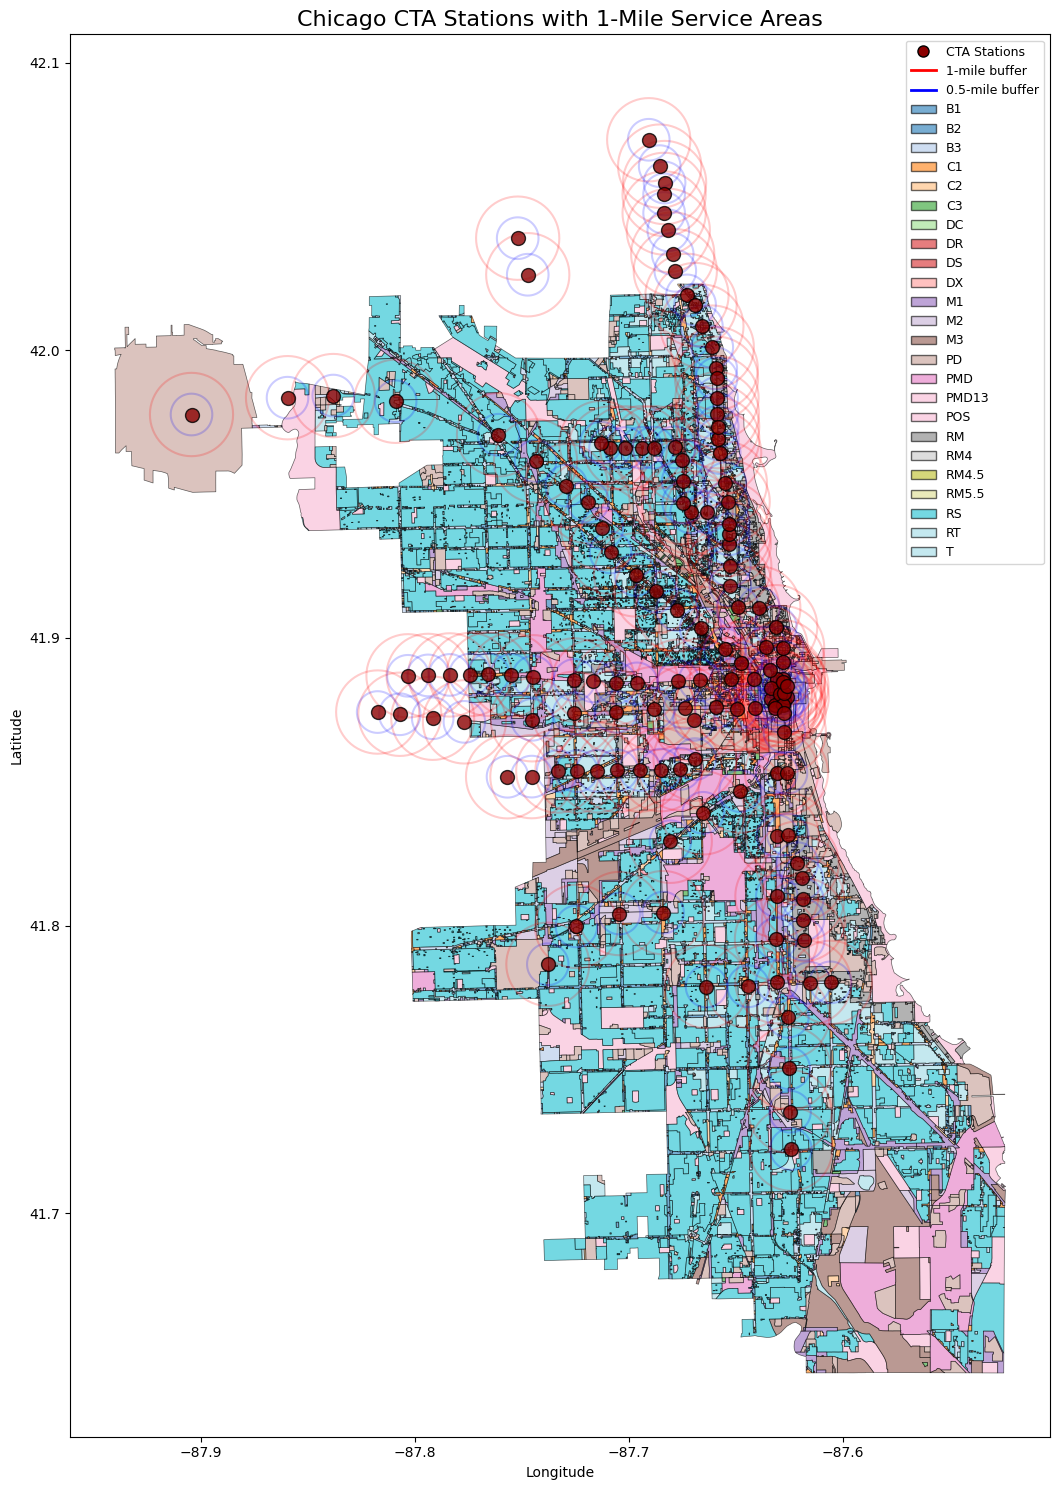

In [281]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Plot station points
ax.scatter(si_gdf['longitude'], si_gdf['latitude'], 
           c='darkred', s=100, alpha=0.8, edgecolors='black', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago CTA Stations with 1-Mile Service Areas', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()


si_gdf['geometry_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

si_gdf['geometry_half_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='blue',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)
# Replace the existing legend so we can show both zone colors and overlays clearly
existing_legend = ax.get_legend()
if existing_legend is not None:
    existing_legend.remove()

zone_legend = ax.legend(
    handles=zone_handles,
    title='Zone Type',
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    fontsize=8,
    title_fontsize=10,
    ncol=2,
    frameon=True
)

ax.add_artist(zone_legend)

# Add a second legend for station/buffer symbology
overlay_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkred',
           markeredgecolor='black', markersize=8, label='CTA Stations'),
    Line2D([0], [0], color='red', lw=2, label='1-mile buffer'),
    Line2D([0], [0], color='blue', lw=2, label='0.5-mile buffer')
]

ax.legend(handles=overlay_handles + zone_handles, loc='upper right', fontsize=9, frameon=True)
plt.show()

In [282]:

for zone_class in zone_classes:
    zone_polygons = zoning_gdf[zoning_gdf['ZONE_TYPE'] == zone_class]['geometry']

    mile_column_name = f"{zone_class}_mile"
    half_mile_column_name = f"{zone_class}_half_mile"
    
    si_gdf[mile_column_name] = si_gdf['geometry_mile'].apply(lambda x: zone_polygons.intersects(x).any())
    si_gdf[half_mile_column_name] = si_gdf['geometry_half_mile'].apply(lambda x: zone_polygons.intersects(x).any())

si_gdf.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,...,RM4.5_mile,RM4.5_half_mile,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,...,False,False,False,False,True,True,True,True,False,False
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,...,False,False,False,False,True,True,True,True,False,False
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,...,False,False,False,False,False,False,True,False,True,False
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False


In [283]:
station_ridership_for_merge = station_ridership.copy()

# Remove columns from station_ridership that are also in si_gdf (except for 'MAP_ID') to avoid conflicts during merge
station_ridership_for_merge = station_ridership.drop(
    columns=[c for c in si_gdf.columns if c in station_ridership.columns and c != 'MAP_ID'],
    errors='ignore'
).copy()

si_gdf_for_merge = si_gdf.copy()
si_gdf_for_merge = si_gdf_for_merge.drop(columns=['geometry', 'geometry_mile', 'geometry_half_mile'], errors='ignore')  

ridership_with_zoning = pd.merge(station_ridership_for_merge, si_gdf_for_merge, on='MAP_ID', how='inner')

ridership_with_zoning.head()

,station_id,stationname,date,daytype,rides,NAME,AWND,PRCP,SNOW,SNWD,...,RM4.5_mile,RM4.5_half_mile,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile
0,40350,UIC-Halsted,2001-01-01,U,273,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",7.61,0.0,0.0,17.0,...,False,False,False,False,False,False,True,True,False,False
1,40350,UIC-Halsted,2001-01-02,W,1775,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",8.50,0.0,0.0,15.0,...,False,False,False,False,False,False,True,True,False,False
2,40350,UIC-Halsted,2001-01-03,W,1945,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",11.41,0.0,0.0,14.0,...,False,False,False,False,False,False,True,True,False,False
3,40350,UIC-Halsted,2001-01-04,W,2049,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",11.63,0.0,0.0,14.0,...,False,False,False,False,False,False,True,True,False,False
4,40350,UIC-Halsted,2001-01-05,W,2145,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",13.87,0.0,0.0,13.0,...,False,False,False,False,False,False,True,True,False,False


In [284]:
result = []

# Which zone types have the most stations nearby (within 1 mile and within half a mile)? And how does ridership differ across these zones?
for zone_class in zone_classes:
    mile_column_name = f"{zone_class}_mile"
    half_mile_column_name = f"{zone_class}_half_mile"
    
    mile_count = si_gdf[mile_column_name].sum()
    half_mile_count = si_gdf[half_mile_column_name].sum()

    result.append({
        'ZONE_TYPE': zone_class,
        'stations_within_mile': mile_count,
        'stations_within_half_mile': half_mile_count
    })

result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by='stations_within_mile', ascending=False)
display(result_df[['ZONE_TYPE', 'stations_within_mile']])

,ZONE_TYPE,stations_within_mile
13,PD,132
16,POS,131
3,C1,124
2,B3,123
4,C2,123
17,RM,119
22,RT,118
0,B1,116
10,M1,114
11,M2,113


In [285]:
result_df = result_df.sort_values(by='stations_within_half_mile', ascending=False)
display(result_df[['ZONE_TYPE', 'stations_within_half_mile']])

,ZONE_TYPE,stations_within_half_mile
13,PD,126
16,POS,119
2,B3,107
22,RT,104
3,C1,103
0,B1,102
17,RM,101
1,B2,93
4,C2,91
21,RS,91


In [293]:
# Which zone types have most average ridership?
result = []
for zone_class in zone_classes:
    mile_column_name = f"{zone_class}_mile"
    half_mile_column_name = f"{zone_class}_half_mile"
    
    avg_rides_mile = ridership_with_zoning[ridership_with_zoning[mile_column_name]]['rides'].mean()
    avg_rides_half_mile = ridership_with_zoning[ridership_with_zoning[half_mile_column_name]]['rides'].mean()

    result.append({
        'ZONE_TYPE': zone_class,
        'avg_rides_within_mile': avg_rides_mile,
        'avg_rides_within_half_mile': avg_rides_half_mile
    })

result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by='avg_rides_within_mile', ascending=False)
display(result_df[['ZONE_TYPE', 'avg_rides_within_mile']])

,ZONE_TYPE,avg_rides_within_mile
6,DC,5234.630913
9,DX,4737.675352
7,DR,4644.992375
8,DS,4638.863061
23,T,3713.805233
12,M3,3175.792035
5,C3,3116.976336
11,M2,3099.579634
13,PD,3060.106555
16,POS,3013.879858


In [294]:
display(result_df[['ZONE_TYPE', 'avg_rides_within_half_mile']])

,ZONE_TYPE,avg_rides_within_half_mile
6,DC,5185.565082
9,DX,4919.911371
7,DR,4332.534870
8,DS,3609.587046
23,T,3632.821143
12,M3,2158.498676
5,C3,1887.378264
11,M2,2228.287330
13,PD,3134.237887
16,POS,3028.816549


In [286]:
#Add extra features to ridership_with_zoning
days_bw_2000_and_lockdown = (pd.to_datetime('2020-03-22') - pd.to_datetime('2000-01-01')).days
ridership_with_zoning['pre_lockdown'] = ridership_with_zoning['days_since_2000'] < days_bw_2000_and_lockdown
ridership_with_zoning['post_lockdown'] = ridership_with_zoning['days_since_2000'] >= days_bw_2000_and_lockdown
ridership_with_zoning['days_since_lockdown'] = ridership_with_zoning['days_since_2000'] - days_bw_2000_and_lockdown

In [287]:
# Build a modeling dataset from ridership_with_zoning
model_df = ridership_with_zoning.copy()

# Keep core temporal/transit features + zoning proximity flags
base_features = [
    'days_since_2000',
    'month',
    'year',
    'latitude',
    'longitude',
    'ADA',
    'RED',
    'BLUE',
    'G',
    'BRN',
    'P',
    'Y',
    'Pnk',
    'O',
    'N/S',
    'E/W',
    'pre_lockdown',
    'post_lockdown',
    'days_since_lockdown',
    'Fog_Ice_Fog',
    'Blowing_Snow',
    
]

zoning_features = [c for c in model_df.columns if c.endswith('_mile') or c.endswith('_half_mile')]
feature_cols = [c for c in base_features if c in model_df.columns] + zoning_features

X = model_df[feature_cols].copy()
y = model_df['rides'].copy()

# Add daytype as dummy variables
daytype_dummies = pd.get_dummies(model_df['daytype'], prefix='daytype', drop_first=True, dtype=int)
X = pd.concat([X, daytype_dummies], axis=1)

season_dummies = pd.get_dummies(model_df['season'], prefix='season', drop_first=True, dtype=int)
X = pd.concat([X, season_dummies], axis=1)

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Force all predictors/target to numeric for statsmodels compatibility
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Drop rows with any missing values in features/target
valid_mask = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

# Optional sampling for speed on very large dataset
sample_n = min(200_000, len(X))
sample_idx = X.sample(n=sample_n).index
X = X.loc[sample_idx]
y = y.loc[sample_idx]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X.astype(float), y.astype(float), test_size=0.2
)

# Fit OLS model
X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

ols_model = sm.OLS(y_train, X_train_const).fit()

# Predict and evaluate
y_pred = ols_model.predict(X_test_const)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")

# Full statistical summary
print(ols_model.summary())

RMSE: 1,660.79
MAE:  1,170.94
R²:   0.7029
                            OLS Regression Results                            
Dep. Variable:                  rides   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     5402.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:13:26   Log-Likelihood:            -1.4127e+06
No. Observations:              160000   AIC:                         2.826e+06
Df Residuals:                  159930   BIC:                         2.826e+06
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [288]:
dt_model = DecisionTreeRegressor(max_depth=10)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)

print(f"Decision Tree RMSE: {mean_squared_error(y_test, y_pred_dt)**0.5:,.2f}")
print(f"Decision Tree R²:   {r2_score(y_test, y_pred_dt):.4f}")


Decision Tree RMSE: 863.12
Decision Tree R²:   0.9198


In [289]:

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest RMSE: {mean_squared_error(y_test, y_pred_rf)**0.5:,.2f}")
print(f"Random Forest R²:   {r2_score(y_test, y_pred_rf):.4f}")

Random Forest RMSE: 829.24
Random Forest R²:   0.9259


4970.82s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
4971.00s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
4971.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
4971.37s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - 

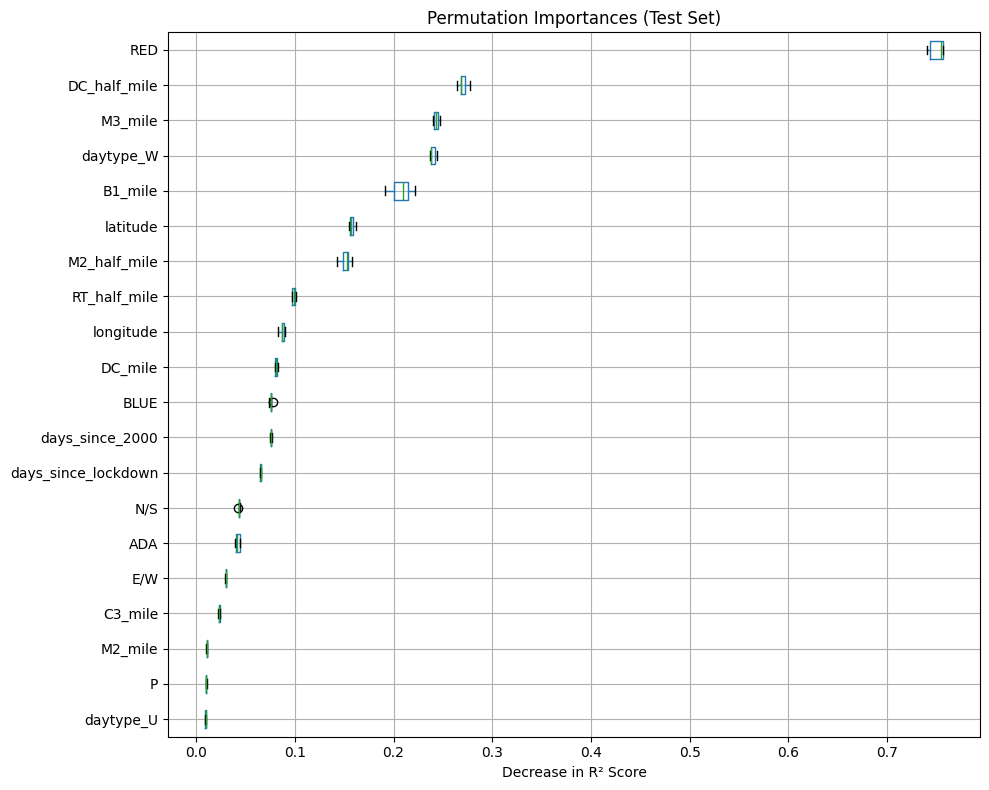

In [290]:
result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# Organize the results
perm_sorted_idx = result.importances_mean.argsort()
perm_df = pd.DataFrame(
    result.importances[perm_sorted_idx].T,
    columns=X.columns[perm_sorted_idx]
)

# Plotting the result
plt.figure(figsize=(10, 8))
perm_df.iloc[:, -20:].boxplot(vert=False, manage_ticks=True)
plt.title("Permutation Importances (Test Set)")
plt.xlabel("Decrease in R² Score")
plt.tight_layout()
plt.show()

Rows used for PCA: 200,000
Original feature count: 341
Components to explain >=95% variance: 145
First 10 explained variance ratios:
[0.05566838 0.03197869 0.01834383 0.01354705 0.01292967 0.01246597
 0.0117967  0.01098135 0.01070434 0.01023894]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC136,PC137,PC138,PC139,PC140,PC141,PC142,PC143,PC144,PC145
224824,4.160071,0.020974,4.921796,2.050025,-0.667778,-0.110865,-0.028470,-0.179429,3.174582,-0.374386,...,0.963843,1.751490,0.711289,0.785328,1.222889,-1.205946,-1.122399,-0.499296,-0.257136,0.896006
752295,-5.579396,7.281390,0.082207,-3.381435,-0.776176,2.916386,-3.689215,1.293294,0.380689,-0.645000,...,0.136846,0.005609,-0.147477,-0.178269,0.096747,-0.030717,-0.021046,-0.119637,-0.004716,0.140279
263749,0.212848,4.366426,-1.997448,3.310578,2.558965,-0.361927,1.538410,0.401782,-3.407277,0.395356,...,2.929692,-0.714178,-1.074031,1.252457,1.303082,0.300052,-1.989194,-0.980025,-1.499455,-0.647566
1165322,3.977730,-0.292546,3.412972,-0.738858,-1.687229,-1.215544,3.714602,1.296811,3.299739,-1.983920,...,0.276713,1.332440,-0.005047,-0.426437,0.553260,-1.721491,0.116963,-2.199486,-0.176040,-0.093827
213863,0.440087,5.618658,0.247369,2.955939,-1.687994,2.188993,1.377290,-0.812435,-4.133648,-0.508566,...,-0.692592,1.056027,0.413217,0.606923,-0.334219,-1.552983,0.239175,0.152822,0.697305,1.019919


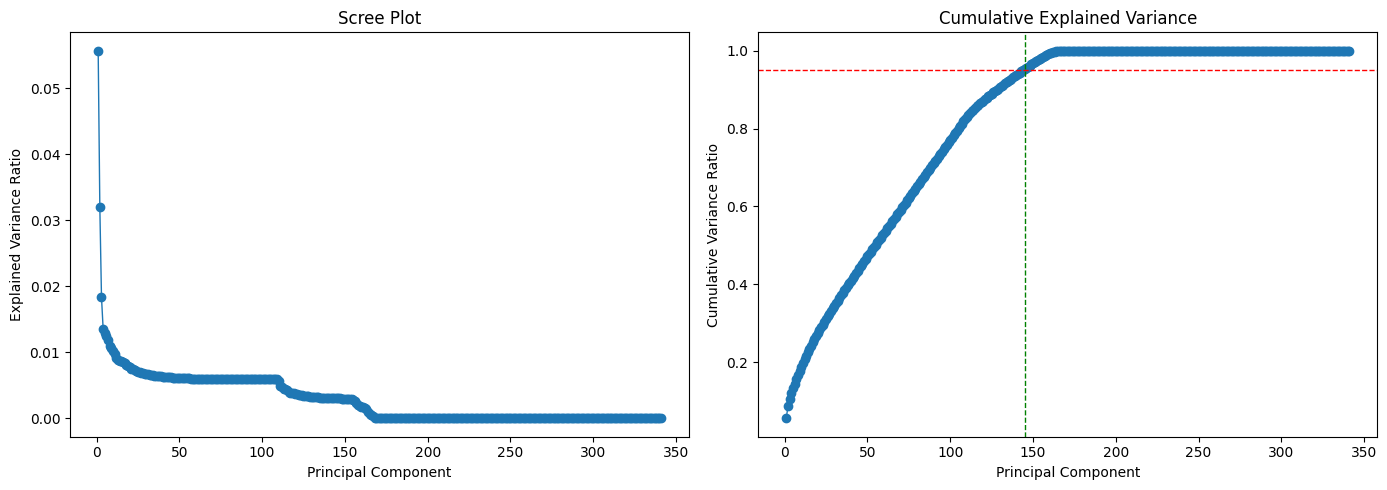

In [291]:
# PCA on ridership_with_zoning (with fallback to ridershipo_with_zoning if that exists)
pca_source_df = ridership_with_zoning.copy()

# Drop non-feature columns that are not directly usable
pca_features = pca_source_df.drop(columns=['date', 'rides'], errors='ignore')

# Encode categorical fields
cat_cols = pca_features.select_dtypes(include=['object', 'category']).columns
pca_features = pd.get_dummies(pca_features, columns=cat_cols, drop_first=True, dtype=int)

# Convert bools and coerce to numeric
bool_cols = pca_features.select_dtypes(include='bool').columns
pca_features[bool_cols] = pca_features[bool_cols].astype(int)
pca_features = pca_features.apply(pd.to_numeric, errors='coerce').dropna()

# Optional sampling for speed
sample_n = min(200_000, len(pca_features))
pca_features = pca_features.sample(n=sample_n)

# Standardize then fit PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_features)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
n95 = np.argmax(cum_explained >= 0.95) + 1

print(f"Rows used for PCA: {len(pca_features):,}")
print(f"Original feature count: {pca_features.shape[1]:,}")
print(f"Components to explain >=95% variance: {n95}")
print(f"First 10 explained variance ratios:\n{explained[:10]}")

# PCA scores dataframe (first n95 components)
si_pca_scores = pd.DataFrame(
    X_pca[:, :n95],
    columns=[f'PC{i+1}' for i in range(n95)],
    index=pca_features.index
)
display(si_pca_scores.head())

# Scree + cumulative variance plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(explained) + 1), explained, marker='o', linewidth=1)
ax[0].set_title('Scree Plot')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')

ax[1].plot(range(1, len(cum_explained) + 1), cum_explained, marker='o', linewidth=1)
ax[1].axhline(0.95, color='red', linestyle='--', linewidth=1)
ax[1].axvline(n95, color='green', linestyle='--', linewidth=1)
ax[1].set_title('Cumulative Explained Variance')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('Cumulative Variance Ratio')

plt.tight_layout()
plt.show()

In [292]:
feature_names = pca_features.columns

# Loadings matrix: rows=original features, cols=PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Show top contributors for first 3 PCs
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop + contributors to {pc}")
    print(loadings[pc].sort_values(ascending=False).head(10))
    print(f"\nTop - contributors to {pc}")
    print(loadings[pc].sort_values(ascending=True).head(10))

# Contribution strength (absolute loading) for PC1/PC2
pc12_contrib = loadings[["PC1", "PC2"]].abs().sort_values("PC1", ascending=False)
display(pc12_contrib.head(20))


Top + contributors to PC1
B3_half_mile    0.215031
RT_half_mile    0.210609
C1_half_mile    0.208900
B1_half_mile    0.206180
B1_mile         0.205575
B2_mile         0.204172
RT_mile         0.200776
RM_half_mile    0.197610
M1_mile         0.192663
RS_mile         0.192051
Name: PC1, dtype: float64

Top - contributors to PC1
DC_half_mile          -0.106069
DC_mile               -0.096487
P                     -0.093061
DX_half_mile          -0.081979
DX_mile               -0.072931
latitude              -0.070267
DR_mile               -0.066290
DS_mile               -0.065947
DR_half_mile          -0.050630
STATION_NAME_Monroe   -0.050053
Name: PC1, dtype: float64

Top + contributors to PC2
DX_mile         0.270995
DS_mile         0.270570
DR_mile         0.270558
DX_half_mile    0.267735
DC_mile         0.252212
DC_half_mile    0.224224
DR_half_mile    0.221696
DS_half_mile    0.221423
longitude       0.181547
M2_mile         0.173448
Name: PC2, dtype: float64

Top - contributors t

,PC1,PC2
B3_half_mile,0.215031,0.036604
RT_half_mile,0.210609,0.059250
C1_half_mile,0.208900,0.009068
B1_half_mile,0.206180,0.053912
B1_mile,0.205575,0.013013
B2_mile,0.204172,0.034609
RT_mile,0.200776,0.001235
RM_half_mile,0.197610,0.012949
M1_mile,0.192663,0.066869
RS_mile,0.192051,0.105328
